# 12.14 先聽寫成文字，怎麼共用聊天歷史？


使用者打字「我不吃辣」，或說出同樣需求。若採先聽寫的路線，希望兩種入口都把文字放進同一段對話，再由同一個聊天核心根據這個條件推薦餐點。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

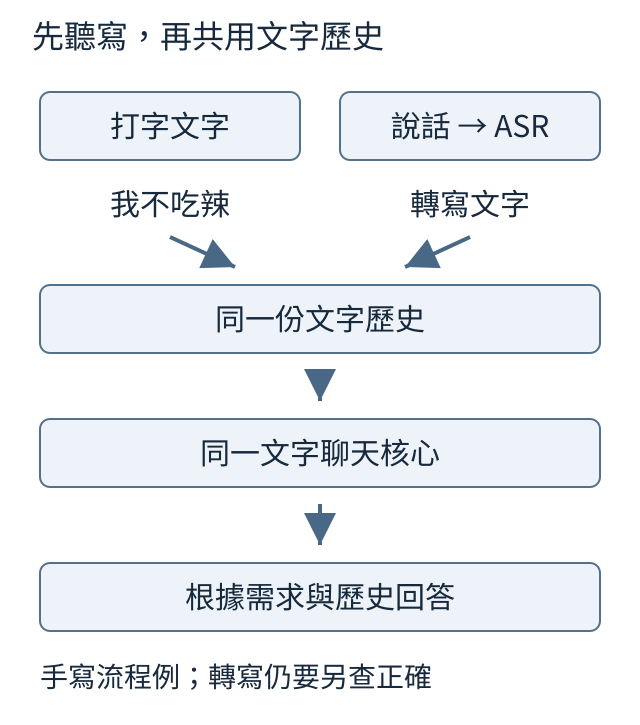

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-12-asr-history.svg")))

自動語音辨識 ASR 負責聲音轉文字，聊天核心負責根據文字與歷史回答。共用核心不等於每段文字都正確；要先分別檢查轉寫與答案。

下面手寫一對轉寫與回覆，讓判準分開看：正確文字是「我不吃辣」，假設轉寫為「我不吃拉」，兩路回答都填「選清淡的湯麵。」。


In [3]:
from tiny_perceptron.natural_concepts import speech_stages

report = speech_stages("我不吃辣", "我不吃拉", "選清淡的湯麵。", "選清淡的湯麵。")
print("聽寫字元錯誤率", report["transcription"]["cer"])
print("兩路回答完全相同", report["answers_identical"])
print("相同是否足以證明正確", report["answers_correct"])

聽寫字元錯誤率 0.25
兩路回答完全相同 True
相同是否足以證明正確 None


「我、不、吃、辣」共四字，有一字替換，聽寫 CER 為 1/4＝0.25。兩路回答相同印 True，但正確性欄是 None，因為函式沒有檢查湯麵配方或是否符合使用者條件。相同與正確仍是不同問題。

若聽寫把「不要加辣」變成「要加辣」，文字核心收到的條件已改變，無法只靠相同聊天程式補救。要報轉寫錯誤，也要用獨立答案判準檢查需求是否被滿足；保留文字歷史可讓下一輪追問「還有別的嗎」沿用已記錄條件。

這種共用歷史可以搭配自行訓練的有限聽寫入口，或第20章成熟 ASR 延伸。接下來的[真人意圖路線](https://birdhackor.github.io/tiny-perceptron-vlm/12.15.html) 不要求先產生逐字稿，而把聲音特徵直接交給同一聊天核心；[12.16](https://birdhackor.github.io/tiny-perceptron-vlm/12.16.html) 會讓這些聲音位置也留在跨入口的歷史中。

練習把轉寫改為「我不吃辣」，CER 應為 0；若兩路仍回相同不合條件的餐點，答案正確性仍要另判。

<details>
<summary>例子與延伸的界線</summary>

本節轉寫與回覆是手寫判準示例，圖解是流程示意。沒有以某段錄音或 ASR 實際輸出作證。第20章當前沿用原底座、未啟用微調修正，成熟模型能力另列延伸，不作自行訓練主線的驗收。

</details>

<details>
<summary>回顧與查證</summary>

可回顧：[12.13聽寫與回答的分工](https://birdhackor.github.io/tiny-perceptron-vlm/12.13.html)、[7.1對話表示](https://birdhackor.github.io/tiny-perceptron-vlm/7.1.html)、[12.11](https://birdhackor.github.io/tiny-perceptron-vlm/12.11.html)。

</details>
